# Data Preprocessing & EDA

1. Initial Data Inspection

Before we start building charts or testing hypotheses, we need to understand the fundamental structure of the dataset. We need to know how large it is, what types of data we are dealing with (numbers vs. text), and—most importantly—if there is any missing data that could break our machine learning models later

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/insurance.csv')

# Check the first 5 rows
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [15]:
# 1. Check the size of the dataset (rows, columns)
print("Dataset Shape (Rows, Columns):", df.shape)
print("\n" + "="*50 + "\n")

# 2. Understand data types and memory usage
print("Dataset Information:")
df.info()
print("\n" + "="*50 + "\n")

# 3. Check for missing values and display them as a neat table
print("Missing Values per Column:")
pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])


Dataset Shape (Rows, Columns): (986, 11)


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


Missing Values per Column:


,Missing Values
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


In [16]:
# 4. Get a statistical summary of the numerical columns
# Note: We use .T (transpose) to flip the table so it's much easier to read
print("Statistical Summary:")
display(df.describe().T)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Age,986.0,41.745436,13.963371,18.0,30.0,42.0,53.0,66.0
Diabetes,986.0,0.419878,0.493789,0.0,0.0,0.0,1.0,1.0
BloodPressureProblems,986.0,0.468560,0.499264,0.0,0.0,0.0,1.0,1.0
AnyTransplants,986.0,0.055781,0.229615,0.0,0.0,0.0,0.0,1.0
AnyChronicDiseases,986.0,0.180527,0.384821,0.0,0.0,0.0,0.0,1.0
Height,986.0,168.182556,10.098155,145.0,161.0,168.0,176.0,188.0
Weight,986.0,76.950304,14.265096,51.0,67.0,75.0,87.0,132.0
KnownAllergies,986.0,0.215010,0.411038,0.0,0.0,0.0,0.0,1.0
HistoryOfCancerInFamily,986.0,0.117647,0.322353,0.0,0.0,0.0,0.0,1.0
NumberOfMajorSurgeries,986.0,0.667343,0.749205,0.0,0.0,1.0,1.0,3.0


2. Visualizing the Target Variable

Before we look at how health factors affect the price, we need to understand the price itself. PremiumPrice is our "Target Variable"—the exact thing our machine learning model will eventually try to predict.

A Histogram (with a density curve): To see the most common premium price ranges and check if the data is skewed (e.g., most people paying low prices, but a few paying extremely high prices).

A Boxplot: This is the absolute best tool for spotting "outliers" (prices that are abnormally high or low compared to the rest of the dataset).

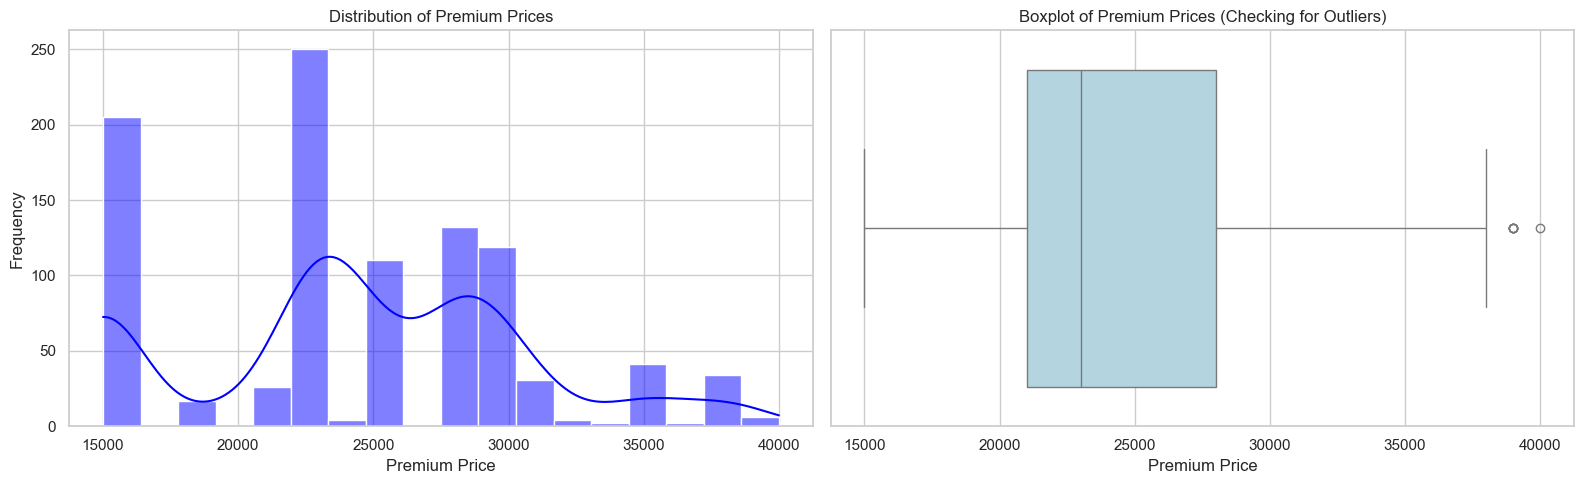

In [17]:
# Set the visual style for all our charts to look professional
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1st Chart: Histogram
sns.histplot(df['PremiumPrice'], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribution of Premium Prices')
axes[0].set_xlabel('Premium Price')
axes[0].set_ylabel('Frequency')

# 2nd Chart: Boxplot
sns.boxplot(x=df['PremiumPrice'], color='lightblue', ax=axes[1])
axes[1].set_title('Boxplot of Premium Prices (Checking for Outliers)')
axes[1].set_xlabel('Premium Price')

# Adjust layout and display
plt.tight_layout()
plt.show()

3. Bivariate Analysis (Health Factors vs. Premium Price)

In this step, we will look at the relationship between two variables at a time (hence "bivariate"). Specifically, we want to see how the different binary health flags (where 0 means No, and 1 means Yes) impact the insurance premium.

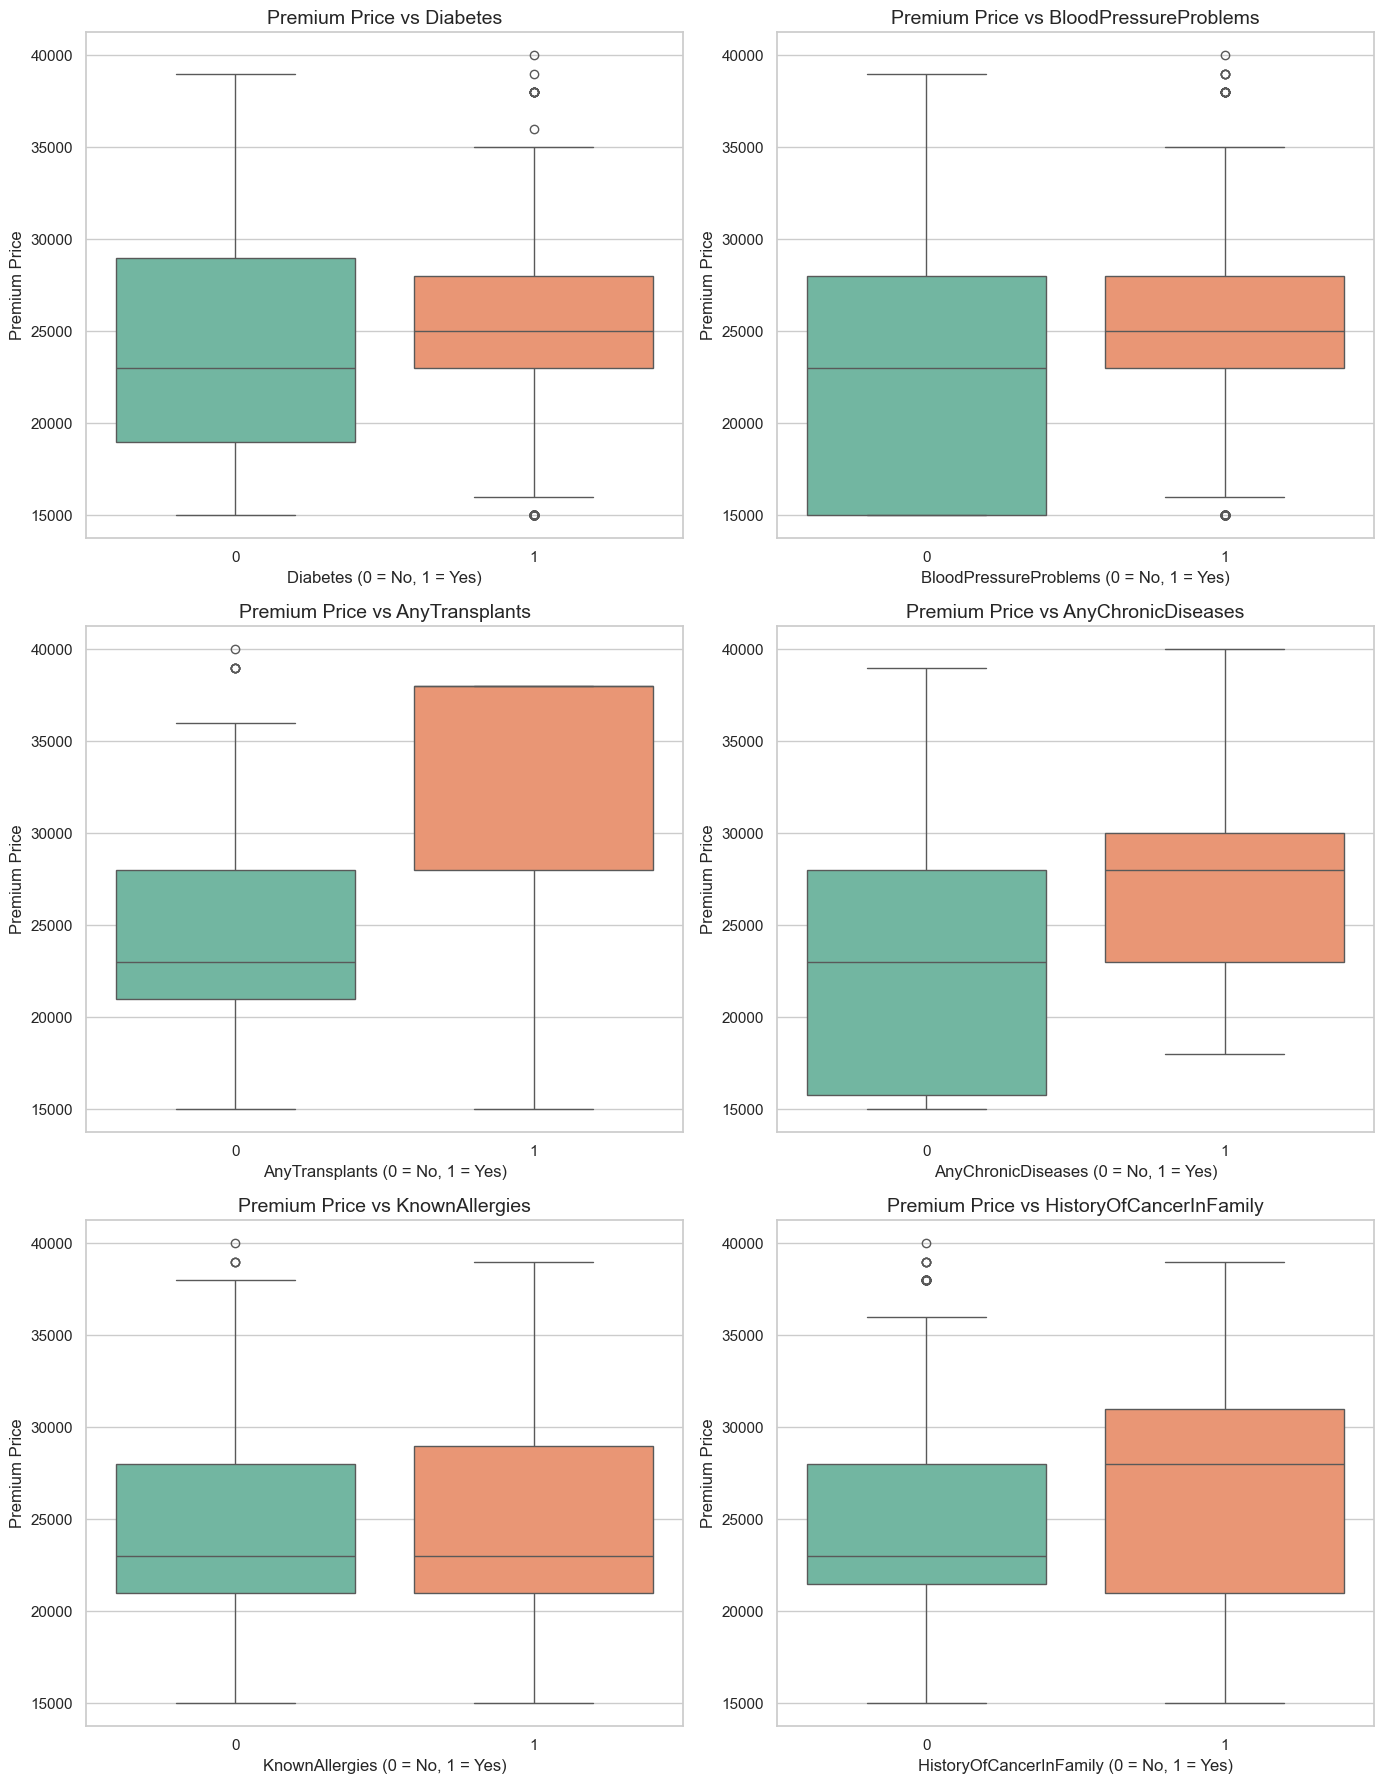

In [18]:
# Create a list of the binary health factors we want to analyze
health_factors = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 
                  'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily']

# Set up a new canvas with 3 rows and 2 columns (taller layout)
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Flatten the axes array to make it easier to loop through
axes = axes.flatten() 

# Loop through our list of factors and draw a boxplot for each one
for i, factor in enumerate(health_factors):
    # Create the boxplot comparing the 0/1 category against PremiumPrice
    sns.boxplot(x=df[factor], y=df['PremiumPrice'], ax=axes[i], palette='Set2', hue=df[factor], legend=False)
    
    # Add titles and labels with slightly larger fonts for readability
    axes[i].set_title(f'Premium Price vs {factor}', fontsize=14)
    axes[i].set_xlabel(factor + ' (0 = No, 1 = Yes)', fontsize=12)
    axes[i].set_ylabel('Premium Price', fontsize=12)

# Adjust the layout so none of the text overlaps
plt.tight_layout()
plt.show()

4. Analyzing Numerical Factors and Surgeries

For continuous numbers (like Age and Weight), scatter plots are the best way to see the trend. For categories like the number of surgeries, we will use another boxplot.

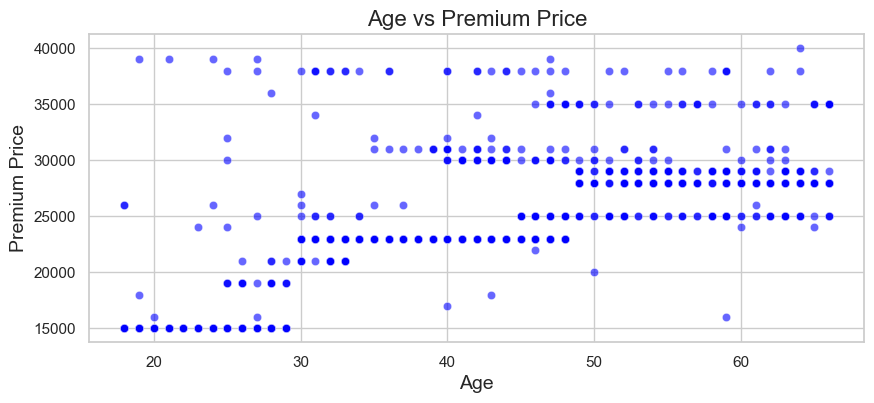

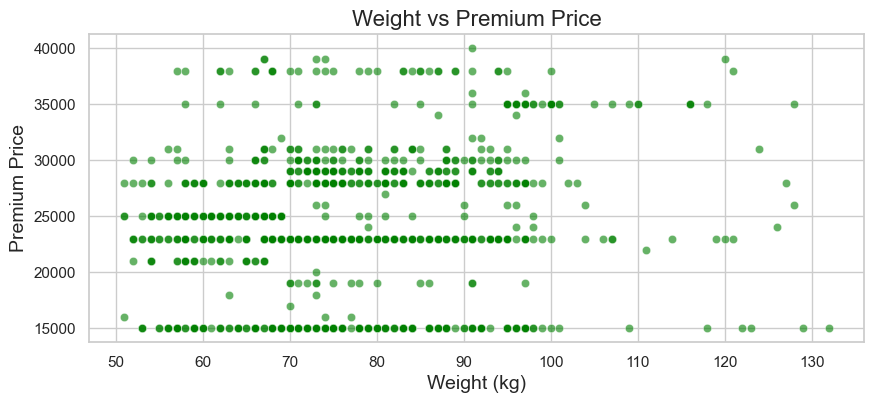

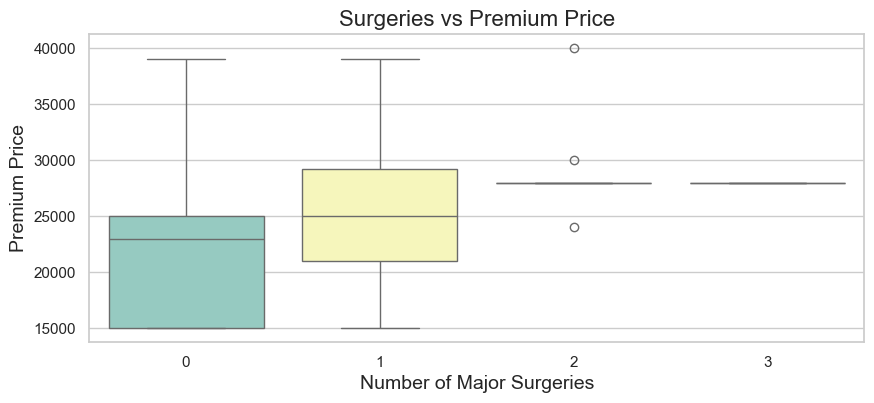

In [19]:
# Bivariate Analysis (Age, Weight, Surgeries vs. Premium Price)
# 1. Age vs Premium Price (Scatter Plot)
plt.figure(figsize=(10, 4))
sns.scatterplot(x=df['Age'], y=df['PremiumPrice'], color='blue', alpha=0.6)
plt.title('Age vs Premium Price', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Premium Price', fontsize=14)
plt.show()

# 2. Weight vs Premium Price (Scatter Plot)
plt.figure(figsize=(10, 4))
sns.scatterplot(x=df['Weight'], y=df['PremiumPrice'], color='green', alpha=0.6)
plt.title('Weight vs Premium Price', fontsize=16)
plt.xlabel('Weight (kg)', fontsize=14)
plt.ylabel('Premium Price', fontsize=14)
plt.show()

# 3. Number of Major Surgeries vs Premium Price (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['NumberOfMajorSurgeries'], y=df['PremiumPrice'], palette='Set3', hue=df['NumberOfMajorSurgeries'], legend=False)
plt.title('Surgeries vs Premium Price', fontsize=16)
plt.xlabel('Number of Major Surgeries', fontsize=14)
plt.ylabel('Premium Price', fontsize=14)
plt.show()

5. The Correlation Heatmap

It calculates the mathematical relationship between every single numerical feature in dataset and displays it as a color-coded grid.
- A score close to 1 means a strong positive relationship (as one goes up, the other goes up).
- A score close to -1 means a strong negative relationship (as one goes up, the other goes down).
- A score close to 0 means no real relationship.

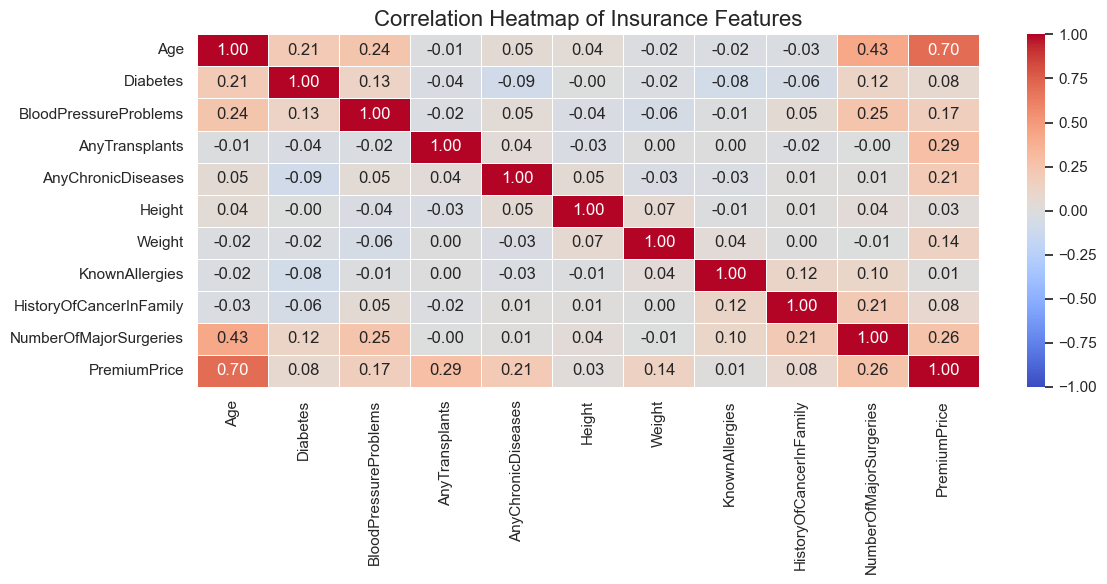

In [20]:
# Calculate the correlation matrix for all columns
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 6))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # Show the actual numbers inside the boxes
            cmap='coolwarm',     # Color scheme: Red for positive, Blue for negative
            fmt=".2f",           # Round numbers to 2 decimal places
            linewidths=0.5,      # Add slight spacing between boxes
            vmin=-1, vmax=1)     # Set the scale from -1 to 1

# Add a title
plt.title('Correlation Heatmap of Insurance Features', fontsize=16)

plt.tight_layout()
plt.show()

# Hypothesis Testing

1. Does the presence of chronic diseases lead to higher insurance premiums? Since we are comparing the average price of two distinct groups (Yes vs. No), we will use an Independent T-test.

2. Is there a significant difference in premium costs based on the number of major surgeries a person has had? Because surgeries have multiple categories (0, 1, 2, or 3), we will use an ANOVA test

In [21]:
import scipy.stats as stats

print("=== STATISTICAL HYPOTHESIS TESTING ===\n")

# ---------------------------------------------------------
# Test 1: Chronic Diseases vs. Premium Price (T-Test)
# ---------------------------------------------------------
# Separate the data into two groups: those with and without chronic diseases
with_chronic = df[df['AnyChronicDiseases'] == 1]['PremiumPrice']
without_chronic = df[df['AnyChronicDiseases'] == 0]['PremiumPrice']

# Perform the Independent T-test
t_stat_chronic, p_val_chronic = stats.ttest_ind(with_chronic, without_chronic)

print("Hypothesis 1: Do Chronic Diseases increase premium costs?")
print(f"T-statistic: {t_stat_chronic:.4f}")
print(f"P-value: {p_val_chronic:.4e}")

# Check if the p-value is less than our threshold (0.05)
if p_val_chronic < 0.05:
    print("Conclusion: REJECT the null hypothesis. There is a statistically significant difference in price.\n")
else:
    print("Conclusion: FAIL TO REJECT the null hypothesis. No significant difference found.\n")

=== STATISTICAL HYPOTHESIS TESTING ===

Hypothesis 1: Do Chronic Diseases increase premium costs?
T-statistic: 6.6910
P-value: 3.7134e-11
Conclusion: REJECT the null hypothesis. There is a statistically significant difference in price.



In [22]:
# ---------------------------------------------------------
# Test 2: Number of Surgeries vs. Premium Price (ANOVA)
# ---------------------------------------------------------
# Separate the premium prices based on the exact number of surgeries
surg_0 = df[df['NumberOfMajorSurgeries'] == 0]['PremiumPrice']
surg_1 = df[df['NumberOfMajorSurgeries'] == 1]['PremiumPrice']
surg_2 = df[df['NumberOfMajorSurgeries'] == 2]['PremiumPrice']
surg_3 = df[df['NumberOfMajorSurgeries'] == 3]['PremiumPrice']

# Perform the One-Way ANOVA test
f_stat_surg, p_val_surg = stats.f_oneway(surg_0, surg_1, surg_2, surg_3)

print("Hypothesis 2: Does the Number of Major Surgeries impact premium costs?")
print(f"F-statistic: {f_stat_surg:.4f}")
print(f"P-value: {p_val_surg:.4e}")

# Check if the p-value is less than our threshold (0.05)
if p_val_surg < 0.05:
    print("Conclusion: REJECT the null hypothesis. There is a statistically significant difference in price based on surgeries.\n")
else:
    print("Conclusion: FAIL TO REJECT the null hypothesis. No significant difference found.\n")

Hypothesis 2: Does the Number of Major Surgeries impact premium costs?
F-statistic: 26.1354
P-value: 2.8712e-16
Conclusion: REJECT the null hypothesis. There is a statistically significant difference in price based on surgeries.



# Machine Learning Modeling

1. Split the Data: We will separate our target (PremiumPrice) from our features (everything else). Then, we will divide the dataset into a Training Set (80% of the data to teach the model) and a Testing Set (20% of the data to quiz the model on data it has never seen).

2. Scale the Features: Factors like Weight are in the 50-130 range, while Diabetes is just 0 or 1. To prevent the algorithm from thinking Weight is 100 times more important simply because the numbers are bigger, we use a StandardScaler to equalize the scales.

3. Train a Baseline Model: We will start with a classic Linear Regression model. This sets our "baseline" score. If our future, more complex models can't beat this score, we know they aren't worth using.

Preprocessing & Baseline Model

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Define Features (X) and Target (y)
X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']

# 2. Train-Test Split (80% training, 20% testing)
# random_state=42 ensures we get the exact same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
# We fit the scaler ONLY on the training data to prevent "data leakage", then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Baseline Model (Linear Regression)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 5. Make Predictions on the Test Set
y_pred_lr = lr_model.predict(X_test_scaled)

# 6. Evaluate the Model
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("=== Baseline Model: Linear Regression ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

=== Baseline Model: Linear Regression ===
Mean Absolute Error (MAE): 2586.23
Root Mean Squared Error (RMSE): 3495.95
R-squared (R2): 0.7134


- An R-squared of 0.7134 is actually a fantastic starting point! It means our simple, straight-line baseline model is already explaining about 71.3% of the variance in premium prices.

- However, from a financial risk assessment perspective, an average error (MAE) of ~2,586 might be a bit too wide of a margin for competitive pricing. When dealing with complex risk profiles, being off by $2.5k on a premium could mean either losing a customer to a competitor or taking a significant hit to profit margins.

Linear Regression assumes the impact of health factors is a perfectly straight line. But we know reality is messier. For instance, age and weight combined with a chronic disease might compound exponentially, not linearly.

To capture those complex, non-linear interactions, we are going to deploy Tree-Based Models: specifically, a Random Forest and a Gradient Boosting Regressor.

In [24]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Train and Predict with Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# 2. Train and Predict with Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

# 3. Evaluate Random Forest
print("=== Model 2: Random Forest Regressor ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R-squared (R2): {r2_score(y_test, y_pred_rf):.4f}\n")

# 4. Evaluate Gradient Boosting
print("=== Model 3: Gradient Boosting Regressor ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_gb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f}")
print(f"R-squared (R2): {r2_score(y_test, y_pred_gb):.4f}")

=== Model 2: Random Forest Regressor ===
MAE: 1034.75
RMSE: 2304.50
R-squared (R2): 0.8755

=== Model 3: Gradient Boosting Regressor ===
MAE: 1501.73
RMSE: 2483.33
R-squared (R2): 0.8554


- The Random Forest model is the absolute champion here.

- The average error (MAE) from ~$2,586 down to ~$1,034 and pushed the R-squared to nearly 88%. That means the model can predict insurance premiums with a high degree of accuracy, giving the business a massive edge in precise risk pricing.

To translate this highly accurate model into actionable business insights, we need to extract its Feature Importances. This will show us exactly which variables the Random Forest relied on the most to calculate that premium price.

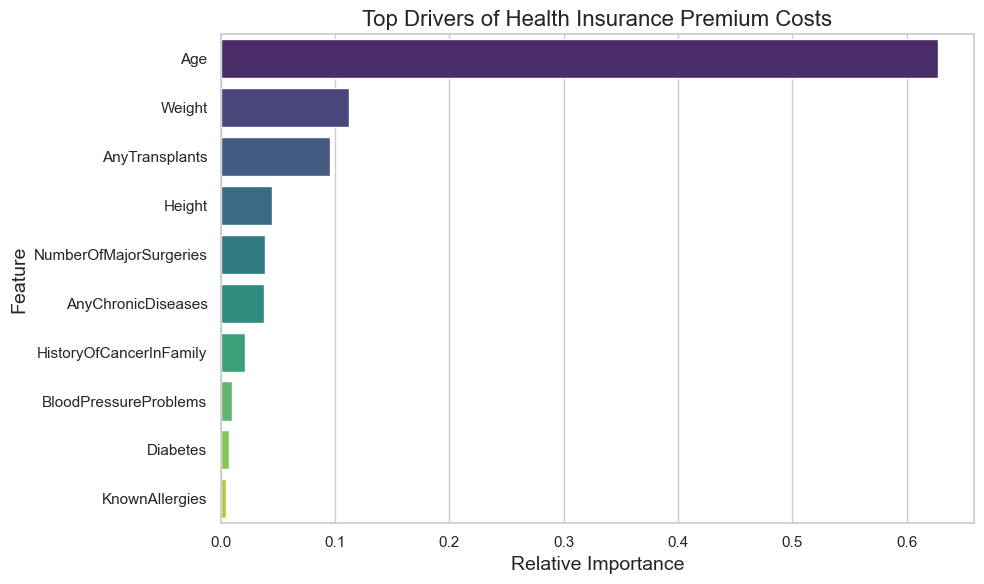

In [25]:
# 1. Extract feature importances from the winning Random Forest model
feature_importances = rf_model.feature_importances_

# 2. Create a DataFrame for easier sorting and plotting
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top Drivers of Health Insurance Premium Costs', fontsize=16)
plt.xlabel('Relative Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tight_layout()
plt.show()

Save our winning Random Forest model and our Scaler as actual files so that our future web application can use them to make predictions.

In [26]:
import joblib
import os

# Ensure the deployment folder exists
os.makedirs('../deployment', exist_ok=True)

# Save the winning Random Forest model and the Scaler to the deployment folder
joblib.dump(rf_model, '../deployment/rf_model.pkl')
joblib.dump(scaler, '../deployment/scaler.pkl')

print("Model and Scaler saved successfully to the deployment folder!")

Model and Scaler saved successfully to the deployment folder!
